<a href="https://colab.research.google.com/github/JuanCarlosAL91/deep-learning-2-TdeA/blob/main/Guia_11_Clasificacion_Texto_HuggingFace.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

AVISO LEGAL — PROPIEDAD INTELECTUAL

Este material es propiedad intelectual exclusiva de Julián David Flórez Sánchez (LinkedIn). Todos los derechos reservados. Queda terminantemente prohibida su copia, reproducción, distribución, adaptación o uso por cualquier persona natural o jurídica, pública o privada, sin autorización expresa y escrita del autor. El incumplimiento de esta disposición acarrea las sanciones civiles y penales previstas en la Ley 23 de 1982, la Decisión Andina 351 de 1993, los artículos 270-272 del Código Penal Colombiano y los tratados internacionales de propiedad intelectual aplicables. Para solicitar autorización: linkedin.com/in/julianflorezdata

# Guia 11: Clasificacion de Texto con Hugging Face Transformers

## Electiva II - Deep Learning | Tecnologico de Antioquia

---

### Objetivo de aprendizaje

Comprender la **arquitectura Transformer** y aplicar **modelos pre-entrenados** (BETO/BERT en espanol) para clasificacion de texto usando la plataforma **Hugging Face**. Al finalizar esta guia, el estudiante sera capaz de usar pipelines pre-entrenados, realizar clasificacion zero-shot y hacer fine-tuning de BETO para tareas de clasificacion en espanol.

### Conceptos nuevos en esta guia

| Concepto | Descripcion |
|----------|-------------|
| **Arquitectura Transformer** | Arquitectura basada enteramente en mecanismos de atencion, sin recurrencia |
| **Mecanismo de Atencion (Self-Attention)** | Permite a cada palabra "prestar atencion" a todas las demas palabras de la secuencia |
| **Embeddings contextuales** | Representaciones vectoriales que cambian segun el contexto (a diferencia de Word2Vec) |
| **BERT** | Bidirectional Encoder Representations from Transformers - modelo pre-entrenado de Google |
| **BETO** | Version de BERT entrenada con un corpus masivo en espanol |
| **Tokenizacion por subpalabras** | WordPiece/BPE: divide palabras desconocidas en subunidades conocidas |
| **Hugging Face Pipeline** | API de alto nivel para usar modelos pre-entrenados en pocas lineas |
| **Fine-tuning** | Ajuste fino de un modelo pre-entrenado para una tarea especifica |
| **Clasificacion Zero-Shot** | Clasificar textos en categorias sin necesidad de datos de entrenamiento |

### Prerrequisito
- **Guia 10:** Word Embeddings y Word2Vec (embeddings estaticos, LSTM para clasificacion)

### Duracion estimada: 3 horas

### Entorno: Google Colab con GPU (OBLIGATORIO)

> **IMPORTANTE - Activar GPU T4:**
> 1. En el menu de Colab, ve a `Entorno de ejecucion` > `Cambiar tipo de entorno de ejecucion`
> 2. En **Acelerador por hardware**, selecciona **GPU T4**
> 3. Haz clic en **Guardar**
> 4. Verifica ejecutando la celda de verificacion de GPU mas abajo
>
> Los modelos Transformer son computacionalmente intensivos. Sin GPU, el fine-tuning puede tardar horas en lugar de minutos.

---

> **Aviso de evaluacion** ✍️: Las preguntas marcadas con ✍️ deben responderse de forma individual. Estas respuestas seran parte de la evaluacion del micro. Responde con tus propias palabras, demostrando comprension profunda de los conceptos.

---

## 1. Configuracion del Entorno

Instalamos las librerias principales:
- **transformers**: la libreria de Hugging Face para usar modelos Transformer
- **datasets**: libreria de Hugging Face para cargar y procesar datasets
- **accelerate**: optimiza el entrenamiento en GPU

In [1]:
# Instalacion de librerias necesarias
!pip install transformers datasets accelerate -q

In [2]:
# Importaciones principales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Hugging Face
from transformers import (
    pipeline,
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)
from datasets import Dataset, DatasetDict

# Scikit-learn para evaluacion
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score
)

# Configuracion de graficos
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print('Todas las importaciones completadas exitosamente')

Todas las importaciones completadas exitosamente


In [3]:
# Verificacion de GPU - OBLIGATORIO
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f'GPU disponible: {torch.cuda.get_device_name(0)}')
    print(f'Memoria GPU: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    device = torch.device('cpu')
    print('ADVERTENCIA: No se detecto GPU.')
    print('Ve a Entorno de ejecucion > Cambiar tipo de entorno > GPU T4')
    print('El fine-tuning sera MUY lento sin GPU.')

print(f'Dispositivo seleccionado: {device}')

GPU disponible: Tesla T4
Memoria GPU: 15.6 GB
Dispositivo seleccionado: cuda


In [4]:
# Fijar semillas para reproducibilidad
import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
print(f'Semilla fijada: {SEED}')

Semilla fijada: 42


---

## 2. Marco Teorico: De Word2Vec a los Transformers

### 2.1 Los limites de Word2Vec y las LSTM

En la Guia 10 trabajamos con **Word2Vec**, que fue revolucionario al crear representaciones densas de palabras que capturan relaciones semanticas. Sin embargo, tiene una **limitacion fundamental**: los embeddings son **estaticos**.

Esto significa que la palabra **"banco"** siempre tendra el mismo vector, sin importar si aparece en:
- *"Fui al **banco** a retirar dinero"* (institucion financiera)
- *"Me sente en el **banco** del parque"* (asiento)
- *"El **banco** de peces nado hacia el norte"* (grupo de peces)

Con Word2Vec, estas tres apariciones de "banco" producen **exactamente el mismo vector**. El modelo no puede distinguir el significado segun el contexto.

Las **LSTM** (Guia 07) intentan capturar contexto procesando la secuencia de forma secuencial (palabra por palabra), pero tienen problemas con:
- **Secuencias largas**: la informacion se degrada al recorrer muchos pasos
- **Procesamiento secuencial**: no se puede paralelizar, el entrenamiento es lento
- **Dependencias lejanas**: si una palabra clave esta muy lejos, la LSTM puede "olvidarla"

### 2.2 La revolucion Transformer (2017)

En 2017, investigadores de Google publicaron el articulo **"Attention is All You Need"** (Vaswani et al.), introduciendo la arquitectura **Transformer**. La idea central fue radical: **eliminar completamente la recurrencia** (RNN/LSTM) y basarse unicamente en mecanismos de **atencion**.

El Transformer original tiene dos partes:
- **Encoder (codificador)**: lee toda la entrada y crea representaciones contextuales
- **Decoder (decodificador)**: genera la salida palabra por palabra

Para clasificacion de texto, solo necesitamos el **Encoder** (que es lo que usa BERT).

### 2.3 Self-Attention: La idea clave

El **mecanismo de auto-atencion (self-attention)** es el corazon del Transformer. La idea es simple pero poderosa:

> **Cada palabra en la oracion puede "prestar atencion" a TODAS las demas palabras simultaneamente para entender su propio significado.**

#### Ejemplo intuitivo

Consideremos la frase: *"El banco del rio estaba lleno de peces"*

Cuando el modelo procesa la palabra **"banco"**, el mecanismo de atencion le permite:
- Mirar la palabra **"rio"** y darle alta importancia
- Mirar la palabra **"peces"** y darle alta importancia
- Mirar la palabra **"El"** y darle baja importancia

Gracias a prestar atencion a "rio" y "peces", el modelo entiende que "banco" se refiere a la orilla del rio, no a una institucion financiera.

En cambio, en *"El banco cerro a las 5 de la tarde"*, la palabra "banco" prestaria atencion a **"cerro"** y **"tarde"**, entendiendo que se refiere a una institucion.

#### Analogia: Query, Key, Value (Q, K, V)

El mecanismo de atencion funciona como un **sistema de busqueda**:

- **Query (Consulta)**: lo que una palabra "pregunta" - *"¿Quien me ayuda a entender mi significado?"*
- **Key (Clave)**: lo que cada palabra "ofrece" - *"Yo soy 'rio', puedo dar contexto geografico"*
- **Value (Valor)**: la informacion real que cada palabra aporta si es seleccionada

El proceso es:
1. La palabra "banco" genera su Query: *"Necesito contexto para saber que tipo de banco soy"*
2. Todas las palabras generan sus Keys: *"rio"→contexto natural, "cerro"→accion temporal, etc.*
3. Se calcula la **similitud** entre la Query de "banco" y las Keys de todas las palabras
4. Las palabras con Keys mas similares a la Query reciben mas **peso de atencion**
5. Se promedian los Values ponderados por esos pesos

#### La formula matematica

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right) V$$

Donde:
- $Q$ = matriz de Queries (cada palabra tiene una query)
- $K$ = matriz de Keys (cada palabra tiene una key)
- $V$ = matriz de Values (cada palabra tiene un value)
- $d_k$ = dimension de las keys (se divide para evitar valores muy grandes)
- $\text{softmax}$ = convierte los puntajes en probabilidades (suman 1)

### 2.4 Multi-Head Attention

Un solo mecanismo de atencion captura **un tipo** de relacion. Pero las palabras pueden relacionarse de multiples formas (sintactica, semantica, de referencia, etc.).

El **Multi-Head Attention** ejecuta **varias cabezas de atencion en paralelo**, cada una aprendiendo a enfocarse en un aspecto diferente:
- **Cabeza 1**: podria aprender relaciones gramaticales (sujeto-verbo)
- **Cabeza 2**: podria aprender relaciones semanticas (banco-rio)
- **Cabeza 3**: podria aprender relaciones de referencia (pronombres)

BERT-base usa **12 cabezas de atencion** en cada capa.

### 2.5 Positional Encoding

A diferencia de las RNN/LSTM que procesan las palabras en orden, el Transformer procesa **todas las palabras simultaneamente**. Esto es excelente para la paralelizacion, pero tiene un problema: **no sabe el orden de las palabras**.

El **Positional Encoding** resuelve esto anadiendo a cada embedding un vector que codifica su **posicion** en la secuencia. Se usan funciones seno y coseno de diferentes frecuencias:

$$PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

$$PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

Asi, el modelo sabe que "El gato come pescado" es diferente de "El pescado come gato".

### 2.6 BERT: Bidirectional Encoder Representations from Transformers

**BERT** (Devlin et al., 2018) tomo el **encoder** del Transformer y lo pre-entreno con dos tareas ingeniosas usando texto sin etiquetar:

1. **Masked Language Model (MLM)**: Se oculta el 15% de las palabras y el modelo debe predecirlas.
   - Entrada: *"El [MASK] del rio estaba lleno de [MASK]"*
   - El modelo aprende: [MASK1] = "banco", [MASK2] = "peces"

2. **Next Sentence Prediction (NSP)**: El modelo recibe dos oraciones y predice si la segunda sigue a la primera.
   - *"El gato se sento en la alfombra"* + *"Ronroneaba suavemente"* → **Si siguen**
   - *"El gato se sento en la alfombra"* + *"Los precios del petroleo subieron"* → **No siguen**

Despues del pre-entrenamiento (que usa millones de textos), BERT aprende representaciones **contextuales** del lenguaje. Luego, para una tarea especifica (como clasificacion), se hace **fine-tuning**: se anade una capa final y se entrena con pocos datos etiquetados.

### 2.7 BETO: BERT en espanol

**BETO** fue desarrollado por la Universidad de Chile (Canete et al., 2020). Es un modelo BERT entrenado con un corpus de **3 mil millones de palabras en espanol**, incluyendo:
- Wikipedia en espanol
- Corpus de las Naciones Unidas
- Otros textos en espanol

BETO entiende las particularidades del espanol: conjugaciones verbales, genero gramatical, modismos, etc. Es significativamente mejor que BERT multilingue para tareas en espanol.

El modelo que usaremos es: `dccuchile/bert-base-spanish-wwm-cased`

### 2.8 Tokenizacion por subpalabras (WordPiece/BPE)

En la Guia 09 tokenizamos por **palabras completas**. BERT usa **tokenizacion por subpalabras**:

- Palabra comun: *"gato"* → `["gato"]` (una sola pieza)
- Palabra menos comun: *"gatitos"* → `["gat", "##itos"]` (dos subpalabras)
- Palabra rara: *"electroencefalograma"* → `["elect", "##roe", "##nce", "##falo", "##grama"]`

Ventajas:
- **Vocabulario finito**: no hay palabras "desconocidas" (OOV)
- **Eficiente**: las palabras comunes son tokens unicos, las raras se descomponen
- **Comparte informacion**: "gato", "gatos", "gatito" comparten la subpalabra "gat"

### 2.9 Hugging Face: Democratizando la IA

**Hugging Face** es una plataforma que ofrece:
- **Model Hub**: miles de modelos pre-entrenados listos para usar
- **Datasets Hub**: miles de datasets para diversas tareas
- **Libreria transformers**: API unificada para usar cualquier modelo
- **Pipeline**: interfaz de alto nivel para usar modelos en 2-3 lineas de codigo

### 2.10 Evolucion de las representaciones de texto

| Enfoque | Guia | Tipo | Contexto | Dimension | Ejemplo |
|---------|------|------|----------|-----------|--------|
| **BoW** | 09 | Disperso | No | Tam. vocabulario | [0,1,0,2,0,...] |
| **TF-IDF** | 09 | Disperso | No | Tam. vocabulario | [0, 0.3, 0, 0.7,...] |
| **Word2Vec** | 10 | Denso | No (estatico) | 100-300 | [0.2, -0.5, 0.8,...] |
| **BERT/BETO** | 11 | Denso | Si (contextual) | 768 | Cambia segun contexto |

---

## 3. Carga y Exploracion de Datos

Trabajaremos con un dataset de **resenas de restaurantes en espanol** con tres clases de sentimiento: **positivo**, **negativo** y **neutro**.

Este dataset simula opiniones reales de clientes sobre restaurantes colombianos y latinoamericanos.

In [5]:
# Dataset de resenas de restaurantes en espanol
# 3 clases: positivo (0), negativo (1), neutro (2)

textos_positivos = [
    'La comida estuvo absolutamente deliciosa, volvere sin duda',
    'Excelente servicio, el mesero fue muy amable y atento',
    'La mejor bandeja paisa que he probado en mi vida',
    'El ambiente es acogedor y la musica muy agradable',
    'Los postres son espectaculares, especialmente el tres leches',
    'Relacion calidad precio inmejorable, muy recomendado',
    'El chef se lucio con el plato del dia',
    'Me encanto la decoracion del restaurante, muy moderno',
    'Las porciones son generosas y todo estaba fresco',
    'El ajiaco estaba perfecto, como el de mi abuela',
    'Increible experiencia gastronomica, de lo mejor de la ciudad',
    'La atencion fue rapida y muy profesional',
    'El ceviche estaba en su punto, fresquisimo',
    'Volvi por segunda vez y sigue igual de bueno',
    'Las empanadas son las mas ricas que he probado',
    'Excelente lugar para una cena romantica',
    'La carta de vinos es impresionante y bien seleccionada',
    'El servicio de domicilio fue rapido y la comida llego caliente',
    'Me fascino el plato de mariscos, super fresco',
    'El restaurante tiene una terraza hermosa con vista a la ciudad',
    'Las arepas de choclo estaban divinas',
    'Todo el menu es delicioso, no hay pierde',
    'El jugo de lulo natural estaba increible',
    'La sopa de la casa es reconfortante y sabrosa',
    'Excelente opcion para ir con toda la familia',
    'El asado estuvo en su punto, jugoso y tierno',
    'Las instalaciones estan impecables, muy limpio todo',
    'El postre de maracuya es una obra de arte',
    'La limonada de coco es la mejor que he tomado',
    'El menu ejecutivo es una ganga por ese precio',
    'Los tamales son autenticos y buenisimos',
    'El cafe colombiano que sirven es de primera calidad',
    'La pizza artesanal tiene una masa espectacular',
    'Me encanto el trato personalizado del dueno',
    'La parrillada mixta es abundante y deliciosa',
    'El arroz con coco estaba en su punto perfecto',
    'Las ensaladas son frescas y muy bien presentadas',
    'El sancocho de gallina es el mejor de Medellin',
    'Tienen opciones vegetarianas deliciosas y variadas',
    'La trucha al ajillo me dejo encantado',
    'Todo salio perfecto para la celebracion de cumpleanos',
    'El pan artesanal que sirven de entrada es adictivo',
    'La crema de ahuyama es suave y deliciosa',
    'El ambiente familiar hace que uno se sienta como en casa',
    'La lulada es refrescante y perfecta para el calor',
    'El pollo asado tiene un sabor unico e increible',
    'Nos atendieron con mucha calidez y profesionalismo',
    'Los jugos naturales son frescos y sin azucar anadida',
    'El plato montanero es contundente y muy sabroso',
    'La torta de chocolate es pecaminosamente deliciosa',
    'Excelente lugar para un almuerzo de negocios',
    'El risotto de hongos estaba cremoso y lleno de sabor',
    'La mojarra frita estaba crujiente por fuera y jugosa por dentro',
    'El servicio es de primera, te hacen sentir especial',
    'Las costillas BBQ estan para chuparse los dedos',
    'La sopa de platano es una delicia que recomiendo',
    'El menu infantil es variado y a los ninos les encanta',
    'La bandeja de mariscos es espectacular y fresca',
    'Los cockteles artesanales son creativos y deliciosos',
    'Cada vez que vengo descubro algo nuevo y delicioso',
    'El filete de res estaba cocinado a la perfeccion',
    'La atencion al detalle en cada plato es admirable',
    'Las arepas rellenas de queso son fantasticas',
    'El helado artesanal de guanabana es unico',
    'Me sorprendio gratamente la calidad del restaurante',
    'El brunch del domingo es una experiencia imperdible',
    'Los nachos con guacamole casero son adictivos',
    'Super recomendado para celebraciones especiales',
    'La comida llega rapido y siempre caliente',
    'Este restaurante se ha convertido en mi favorito',
]

textos_negativos = [
    'La comida estaba fria y sin sabor, muy decepcionante',
    'Esperamos mas de una hora para que nos atendieran',
    'El precio es exagerado para la calidad que ofrecen',
    'Encontre un cabello en mi sopa, inaceptable',
    'El mesero fue grosero y de mal genio',
    'La carne estaba dura como una suela de zapato',
    'El restaurante estaba sucio, las mesas pegajosas',
    'La porcion era minuscula para el precio que cobran',
    'Me enfermo del estomago despues de comer ahi',
    'El ruido era insoportable, no se podia conversar',
    'Pedi mi plato sin picante y vino extra picante',
    'El bano estaba en condiciones deplorables',
    'La comida tenia un sabor rancio, como si no fuera fresca',
    'No aceptan tarjeta y no avisan antes, pesimo servicio',
    'El domicilio tardo dos horas y la comida llego fria',
    'Las bebidas estaban aguadas y sin sabor',
    'El pollo estaba crudo por dentro, peligroso',
    'Cobraron propina obligatoria sin avisarnos',
    'El olor del restaurante era desagradable',
    'La ensalada tenia la lechuga marchita y vieja',
    'Pesimo servicio al cliente, nadie resuelve nada',
    'La sopa estaba salada al punto de no poderse comer',
    'Pedimos la cuenta y tardaron 30 minutos en traerla',
    'El arroz estaba pasado y pegajoso',
    'No habia la mitad de los platos del menu',
    'El aire acondicionado no funcionaba y hacia un calor terrible',
    'Los cubiertos estaban sucios cuando nos los dieron',
    'La musica estaba tan alta que dolia la cabeza',
    'El pescado olia mal, claramente no estaba fresco',
    'Me cobraron de mas y tuve que reclamar',
    'El parqueadero es un desastre, no hay espacio',
    'El postre era un pedacito miserable por doce mil pesos',
    'Las moscas no dejaban comer tranquilo',
    'La comida no se parece en nada a las fotos del menu',
    'Reservamos mesa y cuando llegamos no la tenian',
    'El cafe estaba amargo y parecia recalentado',
    'La pizza estaba quemada por debajo y cruda por encima',
    'Tuve que devolver el plato porque estaba incomible',
    'No hay opciones para vegetarianos ni celiacs',
    'El lugar es claustrofobico, las mesas muy juntas',
    'El jugo supuestamente natural era de caja',
    'La carne tenia nervios y gordo, nada de calidad',
    'El servicio es lentisimo, parece que se olvidan de uno',
    'Habia cucarachas cerca de la cocina, asqueroso',
    'La hamburguesa estaba desabrida y el pan viejo',
    'Nos sentaron al lado del bano y el olor era terrible',
    'El menu es confuso y los precios no estan actualizados',
    'Los meseros estan mas pendientes del celular que de los clientes',
    'La limonada tenia mas agua que limon',
    'Es el peor restaurante al que he ido en mucho tiempo',
    'La sopa del dia parecia agua con color',
    'No volveria ni que me pagaran, pesima experiencia',
    'El arroz con pollo no tenia casi pollo',
    'Las empanadas estaban llenas de grasa',
    'El pan estaba duro y seco, claramente del dia anterior',
    'El frijol estaba crudo y sin sazon',
    'La atencion es pesima, nadie saluda ni da la bienvenida',
    'El local necesita una remodelacion urgente',
    'La comida tardo tanto que se nos quito el hambre',
    'Nunca mas vuelvo a este sitio, una total decepcion',
    'El mesero se equivoco con todos los pedidos de la mesa',
    'La factura tenia errores y no quisieron corregirla',
    'Las papas fritas estaban blandas y aceitosas',
    'El pollo sabia a recalentado del dia anterior',
    'No recomiendo este lugar para nada',
    'La experiencia fue desastrosa de principio a fin',
    'El restaurante huele a humedad y a grasa vieja',
    'La comida no vale lo que cuesta, es un robo',
    'Las sillas son incomodas y estan danadas',
    'El peor servicio de domicilio que he tenido',
]

textos_neutros = [
    'El restaurante queda en la esquina de la calle principal',
    'Abre de lunes a sabado de 11am a 9pm',
    'El menu tiene opciones de carne, pollo y pescado',
    'Tienen servicio de domicilio por aplicacion',
    'El local tiene capacidad para unas 50 personas',
    'Ofrecen menu ejecutivo al mediodia',
    'Aceptan efectivo y tarjetas de credito',
    'El restaurante tiene parqueadero propio',
    'Fui al restaurante un martes al mediodia',
    'El plato vino con arroz, ensalada y papa',
    'El menu cambia cada semana segun la temporada',
    'Tienen wifi gratis para los clientes',
    'Esta ubicado en el centro comercial del barrio',
    'El horario de atencion es de 8am a 10pm',
    'El lugar tiene dos pisos y una terraza',
    'Pedimos la carta y tiene unas veinte opciones',
    'El restaurante lleva cinco anos en el mismo lugar',
    'Hay menu para ninos con porciones mas pequenas',
    'El plato del dia cuesta quince mil pesos',
    'Fuimos un grupo de cuatro personas',
    'La comida tardo unos veinte minutos en llegar',
    'El restaurante tiene mesas adentro y afuera',
    'Sirven desayuno, almuerzo y cena',
    'El menu incluye sopas, platos fuertes y postres',
    'Tienen opciones sin gluten disponibles',
    'El restaurante abre todos los dias incluyendo festivos',
    'La carta esta en espanol y tiene fotos de los platos',
    'Hacen domicilios en un radio de cinco kilometros',
    'El almuerzo ejecutivo incluye sopa, seco, jugo y postre',
    'Ofrecen servicio de catering para eventos',
    'El lugar tiene musica ambiental durante el servicio',
    'Se puede reservar mesa por telefono o por internet',
    'El restaurante esta al lado de la estacion del metro',
    'Los precios van desde diez mil hasta cuarenta mil pesos',
    'El establecimiento cuenta con zona de juegos para ninos',
    'El menu tiene seccion de comida tipica y comida internacional',
    'El local fue remodelado el ano pasado',
    'Tienen diferentes opciones de bebidas calientes y frias',
    'El restaurante esta en la zona gastronomica del pueblo',
    'Fuimos a almorzar el domingo despues de misa',
    'El restaurante tiene cuenta en redes sociales',
    'El menu del dia cambia dependiendo de la disponibilidad',
    'Hacen promociones los miercoles de dos por uno',
    'El chef es de formacion francesa pero cocina comida local',
    'El restaurante pertenece a una cadena con tres sedes',
    'Ofrecen platos individuales y para compartir',
    'Cerraron temprano por un evento privado',
    'El sitio tiene buena iluminacion y ventilacion natural',
    'La carta de postres tiene ocho opciones diferentes',
    'Atienden por orden de llegada, no se necesita reserva',
    'El restaurante fue recomendado por un amigo',
    'Tienen un menu especial para el dia de la madre',
    'El local queda a dos cuadras de la plaza central',
    'Abrieron una nueva sede en el sur de la ciudad',
    'El restaurante tiene una calificacion de 4 estrellas en Google',
    'Hacen descuento del diez por ciento a estudiantes',
    'El dueno es un senor que lleva toda la vida en el negocio',
    'El restaurante tiene decoracion tipica de la region',
    'Fuimos un viernes por la noche y habia bastante gente',
    'El menu incluye las calorias de cada plato',
    'Tienen una barra de ensaladas donde uno se sirve',
    'El restaurante organiza noches de musica en vivo los sabados',
    'La carta tiene opciones desde comida rapida hasta gourmet',
    'El establecimiento tiene certificado de manipulacion de alimentos',
    'El mesero nos explico los platos del dia',
    'Tienen alianza con plataformas de domicilio como Rappi',
]

# Crear listas combinadas
textos = textos_positivos + textos_negativos + textos_neutros

# Etiquetas: 0=positivo, 1=negativo, 2=neutro
etiquetas = ([0] * len(textos_positivos) +
             [1] * len(textos_negativos) +
             [2] * len(textos_neutros))

nombre_clases = {0: 'positivo', 1: 'negativo', 2: 'neutro'}

print(f'Total de resenas: {len(textos)}')
print(f'Positivas: {len(textos_positivos)}')
print(f'Negativas: {len(textos_negativos)}')
print(f'Neutras: {len(textos_neutros)}')

Total de resenas: 206
Positivas: 70
Negativas: 70
Neutras: 66


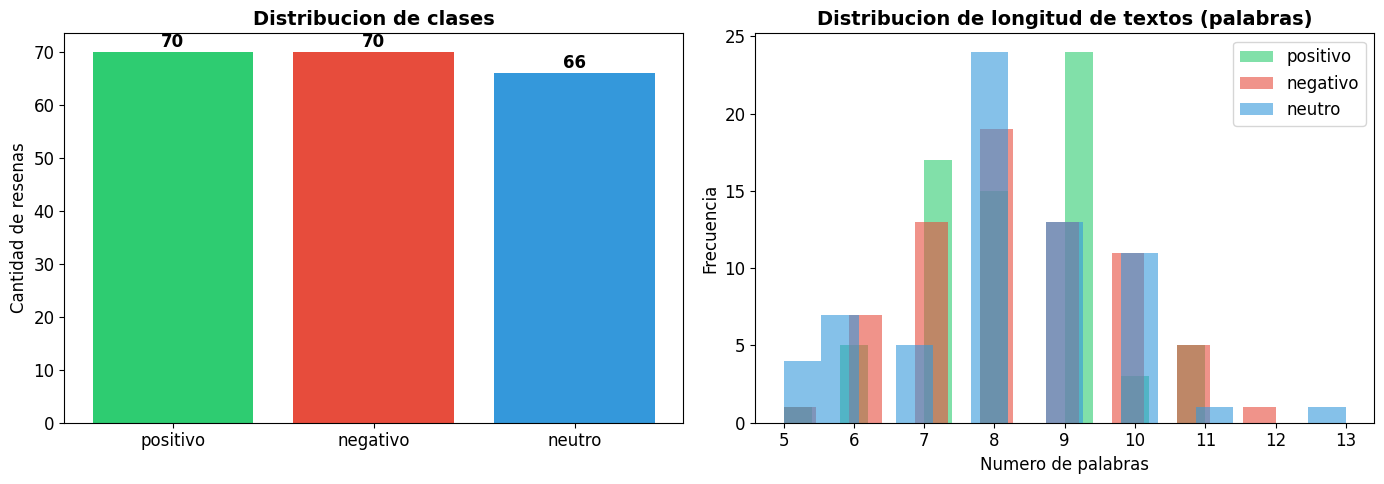


Estadisticas de longitud (palabras) por clase:
          count  mean  std  min  25%  50%  75%   max
clase                                               
negativo   70.0   8.3  1.5  5.0  7.0  8.0  9.0  12.0
neutro     66.0   8.2  1.6  5.0  8.0  8.0  9.0  13.0
positivo   70.0   8.2  1.3  5.0  7.0  8.0  9.0  11.0


In [6]:
# Exploracion del dataset
df = pd.DataFrame({'texto': textos, 'etiqueta': etiquetas})
df['clase'] = df['etiqueta'].map(nombre_clases)
df['longitud'] = df['texto'].apply(len)
df['num_palabras'] = df['texto'].apply(lambda x: len(x.split()))

# Distribucion de clases
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafico de barras - distribucion de clases
conteo = df['clase'].value_counts()
colores = ['#2ecc71', '#e74c3c', '#3498db']
axes[0].bar(conteo.index, conteo.values, color=colores)
axes[0].set_title('Distribucion de clases', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Cantidad de resenas')
for i, v in enumerate(conteo.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

# Histograma de longitud de textos por clase
for clase, color in zip(['positivo', 'negativo', 'neutro'], colores):
    subset = df[df['clase'] == clase]['num_palabras']
    axes[1].hist(subset, bins=15, alpha=0.6, label=clase, color=color)
axes[1].set_title('Distribucion de longitud de textos (palabras)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Numero de palabras')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

plt.tight_layout()
plt.show()

# Estadisticas
print('\nEstadisticas de longitud (palabras) por clase:')
print(df.groupby('clase')['num_palabras'].describe().round(1))

In [7]:
# Ejemplos aleatorios de cada clase
print('=' * 70)
print('EJEMPLOS ALEATORIOS DEL DATASET')
print('=' * 70)
for clase in ['positivo', 'negativo', 'neutro']:
    print(f'\n--- {clase.upper()} ---')
    ejemplos = df[df['clase'] == clase].sample(3, random_state=SEED)
    for _, row in ejemplos.iterrows():
        print(f'  "{row["texto"]}"')

EJEMPLOS ALEATORIOS DEL DATASET

--- POSITIVO ---
  "El jugo de lulo natural estaba increible"
  "La comida estuvo absolutamente deliciosa, volvere sin duda"
  "La torta de chocolate es pecaminosamente deliciosa"

--- NEGATIVO ---
  "Pedimos la cuenta y tardaron 30 minutos en traerla"
  "La comida estaba fria y sin sabor, muy decepcionante"
  "Es el peor restaurante al que he ido en mucho tiempo"

--- NEUTRO ---
  "El restaurante tiene una calificacion de 4 estrellas en Google"
  "La carta tiene opciones desde comida rapida hasta gourmet"
  "El restaurante queda en la esquina de la calle principal"


---

## 4. Experimentacion Guiada

Realizaremos 7 experimentos progresivos, desde el uso mas simple de modelos pre-entrenados hasta el fine-tuning completo de BETO.

---

### Experimento 1: Pipeline de Hugging Face - Lo mas simple

El **pipeline** de Hugging Face es la forma mas facil de usar modelos pre-entrenados. Con solo 2 lineas de codigo podemos hacer analisis de sentimiento.

Usaremos un modelo pre-entrenado en espanol para analisis de sentimiento.

In [8]:
# Experimento 1: Pipeline de analisis de sentimiento
# Usamos un modelo pre-entrenado en espanol
print('Cargando modelo de analisis de sentimiento en espanol...')
print('(La primera vez descarga el modelo, puede tardar un minuto)\n')

clasificador_sentimiento = pipeline(
    'sentiment-analysis',
    model='nlptown/bert-base-multilingual-uncased-sentiment',
    device=0 if torch.cuda.is_available() else -1
)

print('Modelo cargado exitosamente')

Cargando modelo de analisis de sentimiento en espanol...
(La primera vez descarga el modelo, puede tardar un minuto)



config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Modelo cargado exitosamente


In [9]:
# Probar con 10 frases variadas en espanol
frases_prueba = [
    'La comida estuvo absolutamente deliciosa, una maravilla',
    'Pesimo servicio, nunca volvere a este restaurante',
    'El restaurante abre de lunes a viernes',
    'Me encanto el postre de chocolate, increible sabor',
    'La sopa estaba fria y sin ningun sabor',
    'El precio del almuerzo es de quince mil pesos',
    'Excelente atencion, nos trataron como reyes',
    'Encontre una mosca en mi plato, que asco',
    'El lugar queda cerca de la estacion del metro',
    'La mejor experiencia gastronomica de mi vida',
]

print('=' * 70)
print('ANALISIS DE SENTIMIENTO CON PIPELINE DE HUGGING FACE')
print('=' * 70)

for frase in frases_prueba:
    resultado = clasificador_sentimiento(frase)[0]
    etiqueta = resultado['label']
    confianza = resultado['score']
    print(f'\nTexto: "{frase}"')
    print(f'  Prediccion: {etiqueta} | Confianza: {confianza:.4f}')

ANALISIS DE SENTIMIENTO CON PIPELINE DE HUGGING FACE

Texto: "La comida estuvo absolutamente deliciosa, una maravilla"
  Prediccion: 5 stars | Confianza: 0.8006

Texto: "Pesimo servicio, nunca volvere a este restaurante"
  Prediccion: 1 star | Confianza: 0.9497

Texto: "El restaurante abre de lunes a viernes"
  Prediccion: 5 stars | Confianza: 0.3620

Texto: "Me encanto el postre de chocolate, increible sabor"
  Prediccion: 5 stars | Confianza: 0.8300

Texto: "La sopa estaba fria y sin ningun sabor"
  Prediccion: 1 star | Confianza: 0.4559

Texto: "El precio del almuerzo es de quince mil pesos"
  Prediccion: 1 star | Confianza: 0.3689

Texto: "Excelente atencion, nos trataron como reyes"
  Prediccion: 5 stars | Confianza: 0.6948

Texto: "Encontre una mosca en mi plato, que asco"
  Prediccion: 1 star | Confianza: 0.3659

Texto: "El lugar queda cerca de la estacion del metro"
  Prediccion: 3 stars | Confianza: 0.3169

Texto: "La mejor experiencia gastronomica de mi vida"
  Prediccion: 5 

### ✍️ Pregunta 1: Pipeline de Hugging Face

Observa los resultados del pipeline:
1. ¿Que modelo se descargo automaticamente? ¿En cuantas estrellas clasifica?
2. ¿Acerto en la mayoria de los casos? ¿En cuales se equivoco y por que crees que fallo?
3. ¿Que ventaja tiene usar un pipeline pre-entrenado frente a entrenar un modelo desde cero como hicimos en la Guia 10?

### ✍️ Tu respuesta:

****

1. QUE MODELO DESCARGO Y CUANTAS ESTRELLAS CLASIFICA

MODELO: SE DESCARGO AUTOMATICAMENTE nlptown/bert-base-multilingual-uncased-sentiment.

ESTRELLAS: CLASIFICA EN UNA ESCALA DE 1 A 5 ESTRELLAS.

2. ACIERTOS Y CUANTOS ERRORES TUVO
ACIERTO: SI ACERTO EN LOS EXTREMOS DE SENTIMIENTO PURO FRASES MUY POSITIVAS COMO 5 stars O MUY NEGATIVAS COMO 1 star.

ERRORES: FALLO EN LAS FRASES NEUTRAS E INFORMATIVAS YA QUE DIJO QUE HORARIOS ERAN DE 5 stars Y QUE EL PRECIO ERAN DE 1 star.

POR QUE FALLO: POR EL SESGO DE LOS DATOS DE ORIGEN. EL MODELO SE ENTRENO CON RESEÑAS COMERCIALES DE YELP DONDE LA GENTE SOLO ENTRA A CALIFICAR CON ESTRELLAS, POR LO QUE NO ENTIENDE QUE EL TEXTO SOLO ESTA DESCRIBIENDO UN HECHO COMO HORARIO O UN PRECIO SIN OPINAR O VALIDAR.

3. VENTAJA DEL PIPELINE
VENTAJA: LA EFICIENCIA Y EL AHORRO DE TIEMPO PERMITE USAR CONOCIMIENTO DE MILLONES DE DATOS EN SOLO DOS LINEAS DE CODIGO SIN NECESIDAD DE ENTRENAR UNA RED DESDE CERO COMO CON LAS LSTM.


---

### Experimento 2: Clasificacion Zero-Shot

La **clasificacion zero-shot** es uno de los avances mas sorprendentes de los modelos Transformer. Permite clasificar textos en **cualquier categoria que inventes**, sin necesidad de datos de entrenamiento.

El modelo entiende el lenguaje lo suficientemente bien como para determinar si un texto pertenece a una categoria solo con el **nombre de la categoria**.

In [10]:
# Experimento 2: Clasificacion Zero-Shot
# El modelo clasifica sin haber sido entrenado en estas categorias especificas
print('Cargando modelo de clasificacion zero-shot...')

clasificador_zero = pipeline(
    'zero-shot-classification',
    model='facebook/bart-large-mnli',
    device=0 if torch.cuda.is_available() else -1
)

print('Modelo cargado exitosamente')

Cargando modelo de clasificacion zero-shot...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Modelo cargado exitosamente


In [11]:
# Clasificar resenas con nuestras propias categorias
categorias = ['comida deliciosa', 'mal servicio', 'informacion general', 'ambiente agradable']

textos_zero = [
    'El arroz con pollo estaba espectacular y muy bien sazonado',
    'El mesero fue muy grosero y no nos atendio bien',
    'El restaurante abre todos los dias de 10am a 10pm',
    'La terraza tiene una vista hermosa y la musica es relajante',
    'Las empanadas son las mejores que he probado',
    'Tardaron una hora en traernos la comida y estaba fria',
]

print('=' * 70)
print('CLASIFICACION ZERO-SHOT')
print(f'Categorias: {categorias}')
print('=' * 70)

for texto in textos_zero:
    resultado = clasificador_zero(texto, categorias)
    print(f'\nTexto: "{texto}"')
    for etiqueta, puntaje in zip(resultado['labels'], resultado['scores']):
        barra = '█' * int(puntaje * 30)
        print(f'  {etiqueta:25s} {puntaje:.3f} {barra}')

CLASIFICACION ZERO-SHOT
Categorias: ['comida deliciosa', 'mal servicio', 'informacion general', 'ambiente agradable']

Texto: "El arroz con pollo estaba espectacular y muy bien sazonado"
  ambiente agradable        0.528 ███████████████
  comida deliciosa          0.470 ██████████████
  informacion general       0.001 
  mal servicio              0.000 

Texto: "El mesero fue muy grosero y no nos atendio bien"
  mal servicio              0.995 █████████████████████████████
  informacion general       0.003 
  ambiente agradable        0.001 
  comida deliciosa          0.001 

Texto: "El restaurante abre todos los dias de 10am a 10pm"
  ambiente agradable        0.714 █████████████████████
  comida deliciosa          0.203 ██████
  informacion general       0.065 █
  mal servicio              0.018 

Texto: "La terraza tiene una vista hermosa y la musica es relajante"
  ambiente agradable        0.990 █████████████████████████████
  comida deliciosa          0.008 
  informacion genera

In [12]:
# Probar con categorias completamente diferentes e inventadas
categorias_custom = ['urgente', 'recomendacion', 'queja formal', 'dato curioso']

textos_custom = [
    'Necesito hablar con el administrador inmediatamente, esto es inaceptable',
    'Les recomiendo mucho probar el postre de la casa, no se van a arrepentir',
    'El restaurante fue fundado en 1985 por una familia italiana',
    'Quiero poner una queja porque encontre un insecto en mi comida',
]

print('\n' + '=' * 70)
print('ZERO-SHOT CON CATEGORIAS PERSONALIZADAS')
print(f'Categorias: {categorias_custom}')
print('=' * 70)

for texto in textos_custom:
    resultado = clasificador_zero(texto, categorias_custom)
    print(f'\nTexto: "{texto}"')
    print(f'  Prediccion: {resultado["labels"][0]} ({resultado["scores"][0]:.3f})')


ZERO-SHOT CON CATEGORIAS PERSONALIZADAS
Categorias: ['urgente', 'recomendacion', 'queja formal', 'dato curioso']

Texto: "Necesito hablar con el administrador inmediatamente, esto es inaceptable"
  Prediccion: urgente (0.918)

Texto: "Les recomiendo mucho probar el postre de la casa, no se van a arrepentir"
  Prediccion: recomendacion (0.691)

Texto: "El restaurante fue fundado en 1985 por una familia italiana"
  Prediccion: queja formal (0.414)

Texto: "Quiero poner una queja porque encontre un insecto en mi comida"
  Prediccion: urgente (0.389)


### ✍️ Pregunta 2: Clasificacion Zero-Shot

1. ¿Como es posible que el modelo clasifique correctamente sin haber sido entrenado con estas categorias especificas?
2. Inventa 3 categorias nuevas completamente diferentes (por ejemplo: 'solicitud de empleo', 'receta de cocina', 'noticia deportiva') y prueba con textos apropiados. ¿Funciona?
3. ¿En que situaciones reales de una empresa colombiana seria util la clasificacion zero-shot?

### ✍️ Tu respuesta:

****

¿Como es posible que el modelo clasifique correctamente sin haber sido entrenado con estas categorias especificas?

EL MODELO COMPARA EL SIGNIFICADO DE LA FRASE CON EL SIGNIFICADO DE LA CATEGORIA QUE INVENTADA. BUSCA QUE TANTO SE RELACIONAN LAS IDEAS EN SU MEMORIA Y CALCULA CUAL CATEGORIA QUEDA MAS CERCA POR LOGICA SIN NECESITAR EJEMPLOS PREVIOS.

Inventa 3 categorias nuevas completamente diferentes (por ejemplo: 'solicitud de empleo', 'receta de cocina', 'noticia deportiva') y prueba con textos apropiados. ¿Funciona?

CATEGORIAS PROPIAS: HOJA DE VIDA, RECETA GASTRONOMICA, CRONICA DE FUTBOL

FUNCIONA: SI PERO TIENE FALLAS EN ESPAÑOL. FUNCIONA BIEN CON FRASES MUY CLARAS, PERO COMO EL MODELO SE ENTRENO ORIGINALMENTE EN INGLES, EN NUESTRO IDIOMA SE CONFUNDE FACILMENTE. POR ESO ASOCIO UN DATO HISTORICO CON UN RECLAMO.

¿En que situaciones reales de una empresa colombiana seria util la clasificacion zero-shot?

ORDENAR SERVICIO AL CLIENTE COMO EN LA APP RAPI: LEER LOS MENSAJES QUE LLEGAN Y SEPARAR LOS URGENTES DE INMEDIATO PARA ATENDERLOS RAPIDO.

REVISAR REDES SOCIALES: CLASIFICAR LOS COMENTARIOS EN INSTAGRAM EN CARPETAS COMO FELICITACIONES, QUEJAS POR PRECIO O PREGUNTAS.

FILTRAR CORREOS EN RECURSOS HUMANOS: SEPARAR AUTOMATICAMENTE LAS HOJAS DE VIDA QUE LLEGAN DE OTROS CORREOS PUBLICITARIOS.

---

### Experimento 3: Tokenizacion con BETO

Antes de hacer fine-tuning, debemos entender como BETO **tokeniza** el texto. BETO usa tokenizacion por subpalabras (WordPiece), que es muy diferente a la tokenizacion por palabras que usamos con NLTK en la Guia 09.

Cargaremos el tokenizer de BETO y exploraremos como funciona.

In [13]:
# Experimento 3: Tokenizacion con BETO
# Cargar el tokenizer de BETO
print('Cargando tokenizer de BETO...')

nombre_modelo = 'dccuchile/bert-base-spanish-wwm-cased'
tokenizer = AutoTokenizer.from_pretrained(nombre_modelo)

print(f'Modelo: {nombre_modelo}')
print(f'Tamano del vocabulario: {tokenizer.vocab_size}')
print(f'Longitud maxima de secuencia: {tokenizer.model_max_length}')
print(f'Tokens especiales: {tokenizer.all_special_tokens}')

Cargando tokenizer de BETO...


config.json:   0%|          | 0.00/648 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/364 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

Modelo: dccuchile/bert-base-spanish-wwm-cased
Tamano del vocabulario: 31002
Longitud maxima de secuencia: 512
Tokens especiales: ['[UNK]', '[SEP]', '[PAD]', '[CLS]', '[MASK]']


In [14]:
# Tokenizar varias frases y analizar los resultados
frases_tokenizar = [
    'El gato come pescado',
    'El electroencefalograma mostro resultados normales',
    'Me encanto el restaurante',
    'La desoxirribonucleotidiltransferasa es una enzima',
    'El banco del rio estaba lleno de peces',
    'El banco cerro a las 5 de la tarde',
]

print('=' * 70)
print('TOKENIZACION CON BETO (WordPiece)')
print('=' * 70)

for frase in frases_tokenizar:
    # Tokenizar
    tokens = tokenizer.tokenize(frase)
    encoding = tokenizer(frase, return_tensors='pt')

    print(f'\nFrase original:  "{frase}"')
    print(f'Tokens:          {tokens}')
    print(f'Num. tokens:     {len(tokens)}')
    print(f'Input IDs:       {encoding["input_ids"][0].tolist()}')
    print(f'Attention mask:  {encoding["attention_mask"][0].tolist()}')

TOKENIZACION CON BETO (WordPiece)

Frase original:  "El gato come pescado"
Tokens:          ['El', 'gato', 'come', 'pescado']
Num. tokens:     4
Input IDs:       [4, 1162, 10234, 3797, 11243, 5]
Attention mask:  [1, 1, 1, 1, 1, 1]

Frase original:  "El electroencefalograma mostro resultados normales"
Tokens:          ['El', 'electro', '##ence', '##falo', '##grama', 'mostr', '##o', 'resultados', 'normales']
Num. tokens:     9
Input IDs:       [4, 1162, 10503, 11830, 26061, 3715, 8045, 30933, 3338, 11654, 5]
Attention mask:  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

Frase original:  "Me encanto el restaurante"
Tokens:          ['Me', 'encanto', 'el', 'restaurante']
Num. tokens:     4
Input IDs:       [4, 1369, 16480, 1040, 8831, 5]
Attention mask:  [1, 1, 1, 1, 1, 1]

Frase original:  "La desoxirribonucleotidiltransferasa es una enzima"
Tokens:          ['La', 'deso', '##xi', '##r', '##rib', '##on', '##ucle', '##ot', '##idi', '##l', '##trans', '##feras', '##a', 'es', 'una', 'enzima']
Num. token

In [15]:
# Comparacion visual: tokenizacion NLTK vs BETO
# Simulamos tokenizacion simple por palabras (como NLTK)

frases_comparar = [
    'Los gatitos juguetones correteaban alegremente',
    'El electroencefalograma mostro anomalias',
    'Desafortunadamente el restaurante cerro',
]

print('=' * 70)
print('COMPARACION: TOKENIZACION POR PALABRAS vs SUBPALABRAS')
print('=' * 70)

for frase in frases_comparar:
    tokens_simple = frase.lower().split()  # Tokenizacion simple por palabras
    tokens_beto = tokenizer.tokenize(frase)  # Tokenizacion BETO

    print(f'\nFrase: "{frase}"')
    print(f'  Por palabras (NLTK-like): {tokens_simple}')
    print(f'  Por subpalabras (BETO):   {tokens_beto}')
    print(f'  Num. tokens: {len(tokens_simple)} vs {len(tokens_beto)}')

COMPARACION: TOKENIZACION POR PALABRAS vs SUBPALABRAS

Frase: "Los gatitos juguetones correteaban alegremente"
  Por palabras (NLTK-like): ['los', 'gatitos', 'juguetones', 'correteaban', 'alegremente']
  Por subpalabras (BETO):   ['Los', 'ga', '##titos', 'jugue', '##tones', 'corre', '##tea', '##ban', 'alegre', '##mente']
  Num. tokens: 5 vs 10

Frase: "El electroencefalograma mostro anomalias"
  Por palabras (NLTK-like): ['el', 'electroencefalograma', 'mostro', 'anomalias']
  Por subpalabras (BETO):   ['El', 'electro', '##ence', '##falo', '##grama', 'mostr', '##o', 'anomal', '##ias']
  Num. tokens: 4 vs 9

Frase: "Desafortunadamente el restaurante cerro"
  Por palabras (NLTK-like): ['desafortunadamente', 'el', 'restaurante', 'cerro']
  Por subpalabras (BETO):   ['Desaf', '##ortunadamente', 'el', 'restaurante', 'cerro']
  Num. tokens: 4 vs 5


In [16]:
# Tokens especiales de BERT: [CLS] y [SEP]
frase_ejemplo = 'El restaurante es excelente'
encoding = tokenizer(frase_ejemplo, return_tensors='pt')

# Decodificar para ver los tokens especiales
tokens_con_especiales = tokenizer.convert_ids_to_tokens(encoding['input_ids'][0])

print('Tokens especiales de BERT:')
print(f'  [CLS] = token de clasificacion (inicio de secuencia)')
print(f'  [SEP] = separador (fin de secuencia)')
print(f'\nFrase: "{frase_ejemplo}"')
print(f'Tokens con especiales: {tokens_con_especiales}')
print(f'IDs: {encoding["input_ids"][0].tolist()}')
print(f'\nNota: BERT usa la representacion del token [CLS] para clasificacion.')

Tokens especiales de BERT:
  [CLS] = token de clasificacion (inicio de secuencia)
  [SEP] = separador (fin de secuencia)

Frase: "El restaurante es excelente"
Tokens con especiales: ['[CLS]', 'El', 'restaurante', 'es', 'excelente', '[SEP]']
IDs: [4, 1162, 8831, 1058, 7730, 5]

Nota: BERT usa la representacion del token [CLS] para clasificacion.


### ✍️ Pregunta 3: Tokenizacion por subpalabras

1. ¿Por que BETO divide "electroencefalograma" en varios tokens pero "gato" queda como uno solo?
2. ¿Que significan los simbolos `##` al inicio de algunos tokens?
3. ¿Cual es la ventaja principal de la tokenizacion por subpalabras frente a la tokenizacion por palabras completas (como haciamos con NLTK)?
4. Observa las dos frases con la palabra "banco": ¿Los tokens son iguales en ambos casos? ¿Como crees que BERT distingue el significado?

### ✍️ Tu respuesta:

****

¿Por que BETO divide "electroencefalograma" en varios tokens pero "gato" queda como uno solo?

GATO ES UNA PALABRA MUY COMUN QUE EL MODELO SE SABE DE MEMORIA Y LA TIENE ENTERA EN SU LISTA. ELECTROENCEFALOGRAMA ES MUY LARGA Y SE USA POCO POR ESO LA PARTE EN PEDACITOS LAS QUE SI CONOCE.

¿Que significan los simbolos ## al inicio de algunos tokens?

SIGNIFICAN QUE ESE PEDAZO ES LA CONTINUACION DE LA PALABRA Y SIRVE PARA QUE EL MODELO SEPA QUE ESE VA PEGADO AL ANTERIOR Y NO ES UNA PALABRA SUELTA.

¿Cual es la ventaja principal de la tokenizacion por subpalabras frente a la tokenizacion por palabras completas (como haciamos con NLTK)?

LA VENTAJA ES QUE NUNCA SE QUEDA SIN ENTENDER UNA PALABRA. SI ENCUENTRA ALGO NUEVO O RARO LO ROMPE HASTA QUE ENCUENTRA PEDAZOS QUE SI ENTIENDE. ADEMAS HACE QUE EL DICCIONARIO SEA MAS PEQUEÑO Y POR ESO EL COMPUTADOR TRABAJARA MAS RAPIDO.

Observa las dos frases con la palabra "banco": ¿Los tokens son iguales en ambos casos? ¿Como crees que BERT distingue el significado?

LOS TOKENS SON IGUALES: SI SON EL MISMO NUMERO EL ID 6067 PORQUE EL TRADUCTOR SOLO PASA LAS LETRAS A NUMEROS DE FORMA FIJA.

COMO DISTINGUE EL SIGNIFICADO: LO LOGRA REVISANDO LAS PALABRAS VECINAS. EL MODELO MIRA TODO EL CONTEXTO COMO RIO EN UNA FRASE Y CERRO EN LA OTRA Y ASI ENTIENDE CUAL ES EL SIGNIFICADO CORRECTO.

---

### Experimento 4: Fine-Tuning de BETO para Clasificacion

Ahora viene la parte mas importante: vamos a tomar BETO (pre-entrenado en espanol) y **ajustarlo (fine-tuning)** para nuestra tarea especifica de clasificar resenas de restaurantes.

El proceso es:
1. **Tokenizar** todo el dataset con el tokenizer de BETO
2. **Cargar** BETO con una cabeza de clasificacion (3 clases)
3. **Entrenar** con nuestros datos etiquetados usando el Trainer de Hugging Face

Esto es **transfer learning**: aprovechamos todo el conocimiento linguistico que BETO ya aprendio.

In [17]:
# Paso 1: Dividir datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    textos, etiquetas,
    test_size=0.2,
    random_state=SEED,
    stratify=etiquetas
)

print(f'Datos de entrenamiento: {len(X_train)}')
print(f'Datos de prueba: {len(X_test)}')
print(f'\nDistribucion en entrenamiento:')
for clase_id, nombre in nombre_clases.items():
    count = y_train.count(clase_id)
    print(f'  {nombre}: {count}')
print(f'\nDistribucion en prueba:')
for clase_id, nombre in nombre_clases.items():
    count = y_test.count(clase_id)
    print(f'  {nombre}: {count}')

Datos de entrenamiento: 164
Datos de prueba: 42

Distribucion en entrenamiento:
  positivo: 56
  negativo: 56
  neutro: 52

Distribucion en prueba:
  positivo: 14
  negativo: 14
  neutro: 14


In [18]:
# Paso 2: Crear Datasets de Hugging Face
# El Trainer de Hugging Face requiere objetos Dataset

# Tokenizar los textos
def tokenizar_datos(textos, etiquetas):
    """Tokeniza los textos y crea un Dataset de Hugging Face."""
    encodings = tokenizer(
        textos,
        truncation=True,          # Cortar textos muy largos
        padding='max_length',     # Rellenar textos cortos
        max_length=128,           # Longitud maxima de secuencia
        return_tensors=None       # Retornar listas (no tensores)
    )
    dataset = Dataset.from_dict({
        'input_ids': encodings['input_ids'],
        'attention_mask': encodings['attention_mask'],
        'labels': etiquetas
    })
    return dataset

# Crear datasets
dataset_train = tokenizar_datos(X_train, y_train)
dataset_test = tokenizar_datos(X_test, y_test)

print(f'Dataset de entrenamiento: {dataset_train}')
print(f'Dataset de prueba: {dataset_test}')
print(f'\nEjemplo de un registro:')
print(f'  input_ids (primeros 20): {dataset_train[0]["input_ids"][:20]}')
print(f'  attention_mask (primeros 20): {dataset_train[0]["attention_mask"][:20]}')
print(f'  label: {dataset_train[0]["labels"]} ({nombre_clases[dataset_train[0]["labels"]]})')

Dataset de entrenamiento: Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 164
})
Dataset de prueba: Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 42
})

Ejemplo de un registro:
  input_ids (primeros 20): [4, 4787, 20340, 1110, 27114, 4766, 5, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
  attention_mask (primeros 20): [1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  label: 0 (positivo)


In [19]:
# Paso 3: Cargar BETO con cabeza de clasificacion
print('Cargando BETO con cabeza de clasificacion (3 clases)...')

modelo = AutoModelForSequenceClassification.from_pretrained(
    nombre_modelo,
    num_labels=3,  # positivo, negativo, neutro
    id2label=nombre_clases,
    label2id={v: k for k, v in nombre_clases.items()}
)

# Contar parametros
total_params = sum(p.numel() for p in modelo.parameters())
trainable_params = sum(p.numel() for p in modelo.parameters() if p.requires_grad)

print(f'\nModelo cargado: {nombre_modelo}')
print(f'Parametros totales: {total_params:,}')
print(f'Parametros entrenables: {trainable_params:,}')
print(f'\nNota: Estamos re-entrenando TODOS los parametros de BETO')
print(f'mas una nueva capa de clasificacion de 3 clases.')

Cargando BETO con cabeza de clasificacion (3 clases)...


pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not 


Modelo cargado: dccuchile/bert-base-spanish-wwm-cased
Parametros totales: 109,853,187
Parametros entrenables: 109,853,187

Nota: Estamos re-entrenando TODOS los parametros de BETO
mas una nueva capa de clasificacion de 3 clases.


In [20]:
# Paso 4: Definir metricas de evaluacion
def calcular_metricas(eval_pred):
    """Calcula accuracy y F1 durante el entrenamiento."""
    predicciones, etiquetas_reales = eval_pred
    predicciones = np.argmax(predicciones, axis=-1)
    acc = accuracy_score(etiquetas_reales, predicciones)
    f1 = f1_score(etiquetas_reales, predicciones, average='weighted')
    return {'accuracy': acc, 'f1': f1}

print('Funcion de metricas definida')

Funcion de metricas definida


In [21]:
# Paso 5: Configurar argumentos de entrenamiento
argumentos = TrainingArguments(
    output_dir='./resultados_beto',       # Directorio para guardar
    num_train_epochs=4,                    # Numero de epocas
    per_device_train_batch_size=16,        # Tamano de batch
    per_device_eval_batch_size=16,
    learning_rate=2e-5,                    # Learning rate (tipico para fine-tuning BERT)
    weight_decay=0.01,                     # Regularizacion
    eval_strategy='epoch',                 # Evaluar cada epoca
    save_strategy='epoch',                 # Guardar cada epoca
    logging_steps=10,                      # Registrar loss cada 10 pasos
    load_best_model_at_end=True,           # Cargar el mejor modelo al final
    metric_for_best_model='f1',            # Seleccionar mejor modelo por F1
    seed=SEED,
    report_to='none',                      # No reportar a wandb
)

print('Argumentos de entrenamiento configurados:')
print(f'  Epocas: {argumentos.num_train_epochs}')
print(f'  Batch size: {argumentos.per_device_train_batch_size}')
print(f'  Learning rate: {argumentos.learning_rate}')
print(f'  Weight decay: {argumentos.weight_decay}')

Argumentos de entrenamiento configurados:
  Epocas: 4
  Batch size: 16
  Learning rate: 2e-05
  Weight decay: 0.01


In [22]:
# Paso 6: Crear Trainer y ENTRENAR
trainer = Trainer(
    model=modelo,
    args=argumentos,
    train_dataset=dataset_train,
    eval_dataset=dataset_test,
    compute_metrics=calcular_metricas,
)

print('Iniciando fine-tuning de BETO...')
print('(Esto puede tardar unos minutos con GPU)\n')

# Entrenar
historial = trainer.train()

print('\nFine-tuning completado!')
print(f'Tiempo de entrenamiento: {historial.metrics["train_runtime"]:.1f} segundos')
print(f'Loss final: {historial.metrics["train_loss"]:.4f}')

Iniciando fine-tuning de BETO...
(Esto puede tardar unos minutos con GPU)



Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.012111,0.760789,0.809524,0.812874
2,0.685121,0.533288,0.761905,0.749756
3,0.444388,0.387276,0.857143,0.855172
4,0.307148,0.362416,0.880952,0.879752


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Fine-tuning completado!
Tiempo de entrenamiento: 106.3 segundos
Loss final: 0.5814


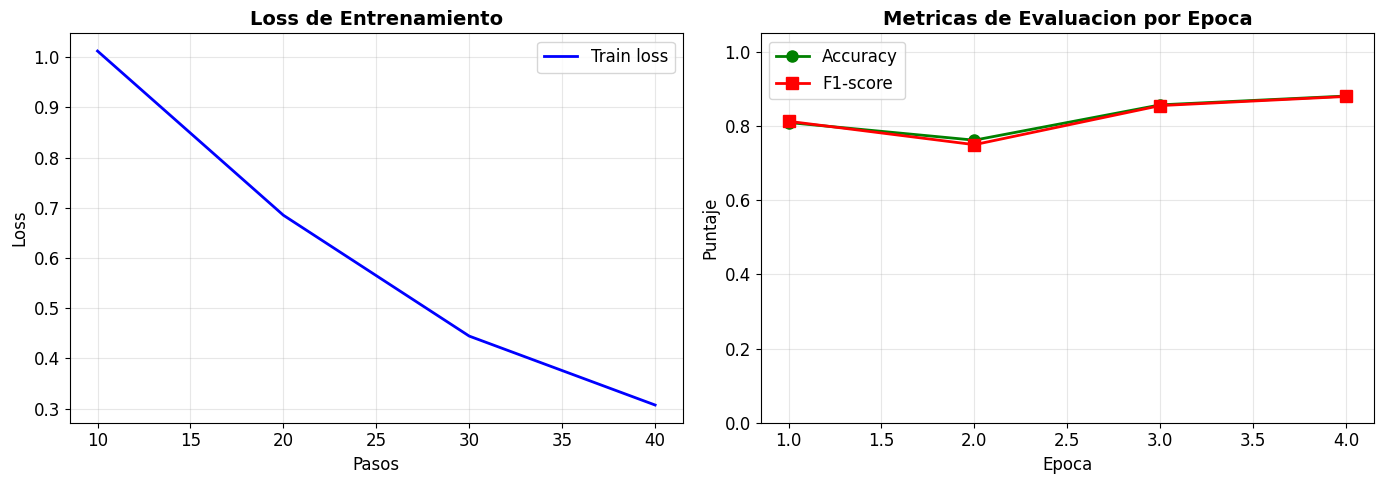

In [23]:
# Paso 7: Graficar la evolucion del entrenamiento
# Extraer el historial de logs
logs = trainer.state.log_history

# Separar loss de entrenamiento y evaluacion
train_loss = [(log['step'], log['loss']) for log in logs if 'loss' in log and 'eval_loss' not in log]
eval_logs = [log for log in logs if 'eval_loss' in log]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss de entrenamiento
if train_loss:
    steps, losses = zip(*train_loss)
    axes[0].plot(steps, losses, 'b-', linewidth=2, label='Train loss')
    axes[0].set_xlabel('Pasos')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Loss de Entrenamiento', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

# Metricas de evaluacion por epoca
if eval_logs:
    epocas = list(range(1, len(eval_logs) + 1))
    eval_acc = [log.get('eval_accuracy', 0) for log in eval_logs]
    eval_f1 = [log.get('eval_f1', 0) for log in eval_logs]

    axes[1].plot(epocas, eval_acc, 'g-o', linewidth=2, label='Accuracy', markersize=8)
    axes[1].plot(epocas, eval_f1, 'r-s', linewidth=2, label='F1-score', markersize=8)
    axes[1].set_xlabel('Epoca')
    axes[1].set_ylabel('Puntaje')
    axes[1].set_title('Metricas de Evaluacion por Epoca', fontsize=14, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    axes[1].set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

### ✍️ Pregunta 4: Fine-Tuning de BETO

1. ¿Cuantos parametros tiene BETO? ¿Como se compara con las redes que entrenamos desde cero en guias anteriores?
2. ¿Por que usamos un learning rate tan bajo (2e-5) para fine-tuning? ¿Que pasaria si usaramos 0.01 como en redes normales?
3. ¿Que significa "fine-tuning" conceptualmente? ¿Por que es mas eficiente que entrenar un modelo desde cero?
4. Observa el grafico de loss: ¿El modelo converge rapidamente o lentamente? ¿Por que crees que es asi?

### ✍️ Tu respuesta:

****
¿Cuantos parametros tiene BETO? ¿Como se compara con las redes que entrenamos desde cero en guias anteriores?

PARAMETROS: TIENE APROXIMADAMENTE 110 MILLONES DE PARAMETROS

COMPARACION: ES ENORME Y LAS REDES QUE SE ENTRENAN DESDE CERO EN LAS GUIAS ANTERIORES APENAS TIENEN UNOS MILES O POCOS MILLONES DE PARAMETROS. BETO TIENE UNA CAPACIDAD DE APRENDIZAJE MUCHO MAYOR.

¿Por que usamos un learning rate tan bajo (2e-5) para fine-tuning? ¿Que pasaria si usaramos 0.01 como en redes normales?

POR QUE BAJO: PORQUE EL MODELO YA SABE HABLAR ESPAÑOL Y SOLO NECESITA UN AJUSTE MUY SUAVE PARA ENFOCARSE EN NUESTRAS RESEÑAS DE LOS RESTAURANTES.

QUE PASARIA CON 0.01: UN PASO TAN GRANDE BORRARIA TODO EL CONOCIMIENTO DEL IDIOMA QUE EL MODELO YA TRAE APRENDIDO DESDE EL PRINCIPIO DAÑANDO LOS RESULTADOS.

¿Que significa "fine-tuning" conceptualmente? ¿Por que es mas eficiente que entrenar un modelo desde cero?

CONCEPTO: SIGNIFICA AJUSTE FINOY ESO IMPLICA TOMAR UN MODELO QUE YA SE ENTRENO CON MILLONES DE TEXTOS GENERICOS Y DARLE UNOS POCOS EJEMPLOS PROPIOS PARA QUE SE VUELVA EXPERTO EN UNA TAREA ESPECIFICA.

POR QUE ES MAS EFICIENTE: PORQUE NO GASTAS TIEMPO NI COMPUTADOR ENSEÑANDOLE AL MODELO A LEER NI A ENTENDER EL IDIOMA DESDE CERO Y  SOLO APROVECHAS LO QUE YA SABE.

Observa el grafico de loss: ¿El modelo converge rapidamente o lentamente? ¿Por que crees que es asi?

CONVERGENCIA: CONVERGE MUY RAPIDO. EN SOLO 40 PASOS EL ERROR BAJA DE MANERA DIRECTA Y SIN TITUBEOS.

POR QUE: PORQUE AL SER UN MODELO PREENTRENADO BETO YA RECONOCE LAS PALABRAS EN ESPAÑOL Y NO TIENE QUE APRENDER QUE SIGNIFICA EXCELENTE O RESTAURANTE SOLO DEBE CONECTAR ESOS SIGNIFICADOS CON LAS 3 ETIQUETAS DE FORMA DIRECTA.

---

### Experimento 5: Evaluacion del Modelo Fine-Tuned

Evaluemos el rendimiento de BETO en el conjunto de prueba y comparemoslo con los enfoques anteriores.

In [24]:
# Experimento 5: Evaluacion completa
print('Evaluando modelo en conjunto de prueba...')

# Obtener predicciones
predicciones_raw = trainer.predict(dataset_test)
y_pred = np.argmax(predicciones_raw.predictions, axis=-1)

# Reporte de clasificacion
print('\n' + '=' * 70)
print('REPORTE DE CLASIFICACION - BETO FINE-TUNED')
print('=' * 70)
print(classification_report(
    y_test, y_pred,
    target_names=['positivo', 'negativo', 'neutro']
))

Evaluando modelo en conjunto de prueba...



REPORTE DE CLASIFICACION - BETO FINE-TUNED
              precision    recall  f1-score   support

    positivo       0.92      0.79      0.85        14
    negativo       0.80      0.86      0.83        14
      neutro       0.93      1.00      0.97        14

    accuracy                           0.88        42
   macro avg       0.88      0.88      0.88        42
weighted avg       0.88      0.88      0.88        42



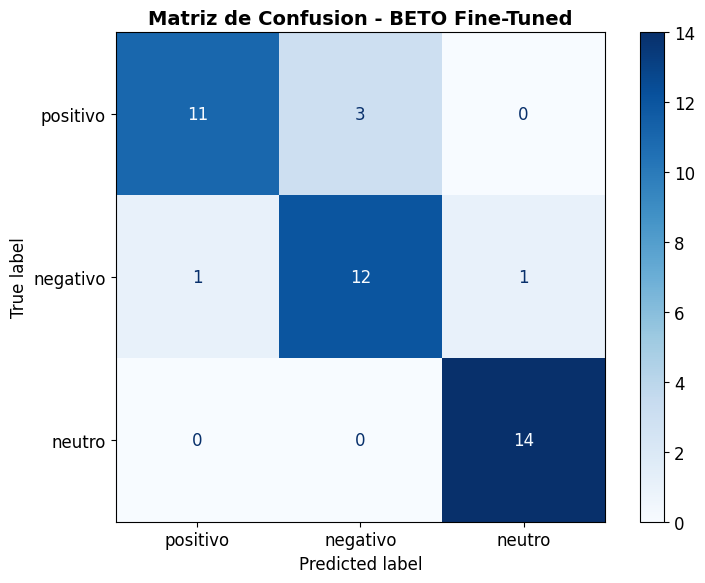

Accuracy global: 0.8810
F1-score ponderado: 0.8798


In [25]:
# Matriz de confusion
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['positivo', 'negativo', 'neutro']
)
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Matriz de Confusion - BETO Fine-Tuned', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Metricas globales
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')
print(f'Accuracy global: {acc:.4f}')
print(f'F1-score ponderado: {f1:.4f}')

COMPARACION DE ENFOQUES (valores representativos)
                      Enfoque     Representacion            Contexto F1 Tipico
BoW + Logistic Reg. (Guia 09)           Dispersa                  No     ~0.70
       TF-IDF + DNN (Guia 09)           Dispersa                  No     ~0.75
    Word2Vec + LSTM (Guia 10)   Densa (estatica)      Parcial (LSTM)     ~0.80
    BETO Fine-Tuned (Guia 11) Densa (contextual) Si (Self-Attention)      0.88


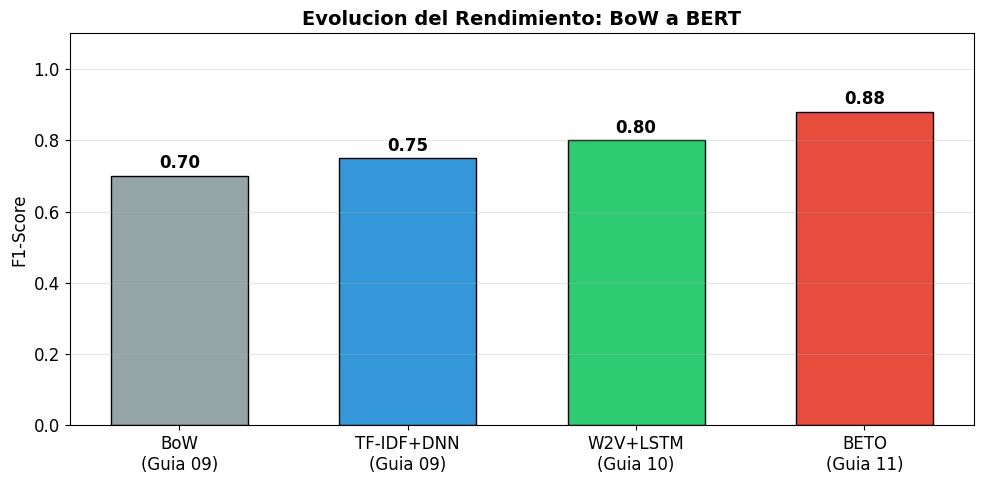

In [26]:
# Comparacion con enfoques anteriores (valores tipicos)
# Estos son valores representativos de las guias anteriores
print('=' * 70)
print('COMPARACION DE ENFOQUES (valores representativos)')
print('=' * 70)

comparacion = {
    'Enfoque': ['BoW + Logistic Reg. (Guia 09)', 'TF-IDF + DNN (Guia 09)',
                'Word2Vec + LSTM (Guia 10)', f'BETO Fine-Tuned (Guia 11)'],
    'Representacion': ['Dispersa', 'Dispersa', 'Densa (estatica)', 'Densa (contextual)'],
    'Contexto': ['No', 'No', 'Parcial (LSTM)', 'Si (Self-Attention)'],
    'F1 Tipico': ['~0.70', '~0.75', '~0.80', f'{f1:.2f}'],
}

df_comp = pd.DataFrame(comparacion)
print(df_comp.to_string(index=False))

# Grafico de comparacion
fig, ax = plt.subplots(figsize=(10, 5))
enfoques = ['BoW\n(Guia 09)', 'TF-IDF+DNN\n(Guia 09)', 'W2V+LSTM\n(Guia 10)', 'BETO\n(Guia 11)']
valores = [0.70, 0.75, 0.80, f1]
colores = ['#95a5a6', '#3498db', '#2ecc71', '#e74c3c']
barras = ax.bar(enfoques, valores, color=colores, width=0.6, edgecolor='black')

for barra, valor in zip(barras, valores):
    ax.text(barra.get_x() + barra.get_width()/2., barra.get_height() + 0.01,
            f'{valor:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=12)

ax.set_ylabel('F1-Score', fontsize=12)
ax.set_title('Evolucion del Rendimiento: BoW a BERT', fontsize=14, fontweight='bold')
ax.set_ylim([0, 1.1])
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### ✍️ Pregunta 5: Evaluacion y Comparacion

1. ¿Cual fue el F1-score de BETO? ¿Supero a los enfoques anteriores?
2. Mirando la matriz de confusion, ¿que clase es la mas dificil de clasificar? ¿Por que crees que es asi?
3. Si BETO tiene 110 millones de parametros y nuestro dataset tiene solo ~200 textos, ¿no deberia haber overfitting severo? ¿Por que funciona el fine-tuning con pocos datos?

### ✍️ Tu respuesta:

****
¿Cual fue el F1-score de BETO? ¿Supero a los enfoques anteriores?
F1-SCORE: FUE DE 0.88.

COMPARACION: SI LES GANO A TODOS Y SUPERO LAS GUIAS PASADAS.

Mirando la matriz de confusion, ¿que clase es la mas dificil de clasificar? ¿Por que crees que es asi?

MAS DIFICIL: LOS POSITIVOS.

POR QUE: EL MODELO SE CONFUNDIO Y LOS MARCO COMO NEGATIVOS LO CUAL PASA PORQUE HAY FRASES TRAICIONERAS DONDE COMIENZAN HABLANDO MAL DEL LUGAR PERO AL FINAL DICEN QUE LA COMIDA ES EXCELENTE. EL MODELO SE ENREDA CON EL INICIO DE LA FRASE.

Si BETO tiene 110 millones de parametros y nuestro dataset tiene solo ~200 textos, ¿no deberia haber overfitting severo? ¿Por que funciona el fine-tuning con pocos datos?

RESPUESTA: NO PORQUE BETO YA SABE HABLAR ESPAÑOL YA LE ENSEÑARON TODO EL IDIOMA CON MILLONES DE FRASES ANTES NOSOTROS SOLO LE ESTAMOS DANDO EL TOQUE FINAL PARA QUE SE ENFOQUE EN RESTAURANTES Y ESO SE LLAMA TRANSFER LEARNING.


---

### Experimento 6: Analisis de Errores

Un buen cientifico de datos no solo reporta metricas: **analiza donde y por que falla el modelo**.

In [27]:
# Experimento 6: Analisis de errores
# Encontrar los textos donde el modelo se equivoco

errores = []
for i in range(len(y_test)):
    if y_test[i] != y_pred[i]:
        errores.append({
            'texto': X_test[i],
            'real': nombre_clases[y_test[i]],
            'predicho': nombre_clases[y_pred[i]],
        })

print(f'Total de errores: {len(errores)} de {len(y_test)} ({len(errores)/len(y_test)*100:.1f}%)')
print('\n' + '=' * 70)
print('ANALISIS DE ERRORES')
print('=' * 70)

if len(errores) > 0:
    for i, error in enumerate(errores):
        print(f'\nError {i+1}:')
        print(f'  Texto: "{error["texto"]}"')
        print(f'  Real: {error["real"]} | Predicho: {error["predicho"]}')
else:
    print('\nEl modelo clasifico correctamente TODOS los textos del conjunto de prueba.')
    print('Esto puede indicar que el dataset es relativamente simple para BETO.')
    print('Probemos con textos mas dificiles en el siguiente experimento.')

Total de errores: 5 de 42 (11.9%)

ANALISIS DE ERRORES

Error 1:
  Texto: "La mejor bandeja paisa que he probado en mi vida"
  Real: positivo | Predicho: negativo

Error 2:
  Texto: "El mesero se equivoco con todos los pedidos de la mesa"
  Real: negativo | Predicho: neutro

Error 3:
  Texto: "La mojarra frita estaba crujiente por fuera y jugosa por dentro"
  Real: positivo | Predicho: negativo

Error 4:
  Texto: "Las arepas de choclo estaban divinas"
  Real: positivo | Predicho: negativo

Error 5:
  Texto: "Los meseros estan mas pendientes del celular que de los clientes"
  Real: negativo | Predicho: positivo


In [28]:
# Analisis con textos deliberadamente dificiles
textos_dificiles = [
    'La comida no estaba nada mal',                          # Doble negacion (positivo)
    'Que rico que me cobren tanto por tan poca comida',      # Sarcasmo (negativo)
    'El restaurante estaba vacio, sera por algo',            # Ironia (negativo)
    'No puedo decir que la comida sea mala',                 # Doble negacion (positivo)
    'Para ser un lugar economico, la comida es aceptable',   # Ambiguo (neutro/positivo)
    'El servicio fue interesante, por decir algo',           # Ironia (negativo)
    'La verdad es que he comido peores cosas',               # Positivo indirecto
    'Me quede con hambre pero al menos no me enfermo',       # Mixto (negativo)
]

print('=' * 70)
print('TEXTOS DIFICILES: SARCASMO, IRONIA Y DOBLE NEGACION')
print('=' * 70)

# Tokenizar y predecir
for texto in textos_dificiles:
    inputs = tokenizer(texto, return_tensors='pt', truncation=True, max_length=128, padding='max_length')
    inputs = {k: v.to(modelo.device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = modelo(**inputs)

    probs = torch.softmax(outputs.logits, dim=-1)[0]
    pred_clase = torch.argmax(probs).item()

    print(f'\nTexto: "{texto}"')
    print(f'  Prediccion: {nombre_clases[pred_clase]}')
    for clase_id, nombre in nombre_clases.items():
        barra = '█' * int(probs[clase_id].item() * 30)
        print(f'    {nombre:10s}: {probs[clase_id].item():.3f} {barra}')

TEXTOS DIFICILES: SARCASMO, IRONIA Y DOBLE NEGACION

Texto: "La comida no estaba nada mal"
  Prediccion: negativo
    positivo  : 0.109 ███
    negativo  : 0.863 █████████████████████████
    neutro    : 0.028 

Texto: "Que rico que me cobren tanto por tan poca comida"
  Prediccion: negativo
    positivo  : 0.176 █████
    negativo  : 0.785 ███████████████████████
    neutro    : 0.039 █

Texto: "El restaurante estaba vacio, sera por algo"
  Prediccion: negativo
    positivo  : 0.096 ██
    negativo  : 0.861 █████████████████████████
    neutro    : 0.044 █

Texto: "No puedo decir que la comida sea mala"
  Prediccion: negativo
    positivo  : 0.206 ██████
    negativo  : 0.755 ██████████████████████
    neutro    : 0.039 █

Texto: "Para ser un lugar economico, la comida es aceptable"
  Prediccion: positivo
    positivo  : 0.697 ████████████████████
    negativo  : 0.185 █████
    neutro    : 0.118 ███

Texto: "El servicio fue interesante, por decir algo"
  Prediccion: negativo
    posi

### ✍️ Pregunta 6: Analisis de Errores

1. ¿En cuantos textos del conjunto de prueba se equivoco el modelo? ¿Te parece un buen resultado?
2. Observa los textos dificiles (sarcasmo, ironia, doble negacion). ¿En cuales acerto y en cuales fallo?
3. ¿Por que el sarcasmo es tan dificil para los modelos de lenguaje? ¿Que tendria que "entender" un modelo para detectar sarcasmo?
4. ¿Se te ocurre alguna estrategia para mejorar el rendimiento en textos sarcasticos o ironicos?

### ✍️ Tu respuesta:

****
¿En cuantos textos del conjunto de prueba se equivoco el modelo? ¿Te parece un buen resultado?

ERRORES: FALLO EN 5 DE 42

EVALUACION: SI ES EXCELENTE Y LOGRO MAS DE 88% DE ACIERTOS EN UN GRUPO MUY PEQUEÑO.

Observa los textos dificiles (sarcasmo, ironia, doble negacion). ¿En cuales acerto y en cuales fallo?

ACERTO: EN SARCASMO E IRONIA COMO QUE RICO QUE ME COBREN TANTO. LOS MARCO BIEN COMO NEGATIVOS.

FALLO: EN DOBLES NEGACIONES COMO NO ESTABA NADA MAL. LOS MARCO MAL COMO NEGATIVOS PORQUE SE LO ENGAÑO LA PALABRA MAL.

¿Por que el sarcasmo es tan dificil para los modelos de lenguaje? ¿Que tendria que "entender" un modelo para detectar sarcasmo?

POR QUE: PORQUE DICE LO CONTRARIO DE LO QUE SIGNIFICA PERO USANDO PALABRAS BUENAS PARA COSAS MALAS.

QUE DEBE ENTENDER: EL SENTIDO COMUN Y DEBERIA SABER QUE PAGAR MUCHO POR POCO NUNCA ES BUENO.

¿Se te ocurre alguna estrategia para mejorar el rendimiento en textos sarcasticos o ironicos?

ESTRATEGIA: AGREGAR AL ENTRENAMIENTO CIENTOS DE FRASES CON SARCASMO SACADAS DE INTERNET PARA QUE EL MODELO APRENDA Y TENGA TODOS LOS CONTEXTOS Y SITUACIONES.

---

### Experimento 7: Probar con Textos Propios

Ahora es tu turno. Escribe tus propios textos y observa como los clasifica el modelo.

In [29]:
# Experimento 7: Escribe tus propios textos
# Modifica esta lista con tus propias resenas

mis_textos = [
    # Escribe aqui tus 10 textos propios
    'Escribe tu primera resena aqui',
    'Escribe tu segunda resena aqui',
    'Escribe tu tercera resena aqui',
    'Escribe tu cuarta resena aqui',
    'Escribe tu quinta resena aqui',
    'Escribe tu sexta resena aqui',
    'Escribe tu septima resena aqui',
    'Escribe tu octava resena aqui',
    'Escribe tu novena resena aqui',
    'Escribe tu decima resena aqui',
]

print('=' * 70)
print('CLASIFICACION DE TUS TEXTOS PROPIOS')
print('=' * 70)

for texto in mis_textos:
    inputs = tokenizer(texto, return_tensors='pt', truncation=True, max_length=128, padding='max_length')
    inputs = {k: v.to(modelo.device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = modelo(**inputs)

    probs = torch.softmax(outputs.logits, dim=-1)[0]
    pred_clase = torch.argmax(probs).item()
    confianza = probs[pred_clase].item()

    print(f'\nTexto: "{texto}"')
    print(f'  Prediccion: {nombre_clases[pred_clase]} (confianza: {confianza:.3f})')

CLASIFICACION DE TUS TEXTOS PROPIOS

Texto: "Escribe tu primera resena aqui"
  Prediccion: positivo (confianza: 0.544)

Texto: "Escribe tu segunda resena aqui"
  Prediccion: positivo (confianza: 0.437)

Texto: "Escribe tu tercera resena aqui"
  Prediccion: positivo (confianza: 0.399)

Texto: "Escribe tu cuarta resena aqui"
  Prediccion: negativo (confianza: 0.510)

Texto: "Escribe tu quinta resena aqui"
  Prediccion: negativo (confianza: 0.550)

Texto: "Escribe tu sexta resena aqui"
  Prediccion: negativo (confianza: 0.490)

Texto: "Escribe tu septima resena aqui"
  Prediccion: negativo (confianza: 0.467)

Texto: "Escribe tu octava resena aqui"
  Prediccion: negativo (confianza: 0.445)

Texto: "Escribe tu novena resena aqui"
  Prediccion: negativo (confianza: 0.453)

Texto: "Escribe tu decima resena aqui"
  Prediccion: negativo (confianza: 0.430)


In [30]:
# Textos especialmente dificiles: sarcasmo y doble sentido
# Intenta escribir textos que confundan al modelo

textos_trampa = [
    # Modifica estos con tus propios textos sarcasticos o confusos
    'Escribe aqui un texto sarcastico para confundir al modelo',
    'Escribe aqui otro texto con doble sentido',
    'Escribe aqui un texto ambiguo',
]

print('=' * 70)
print('TEXTOS DIFICILES - INTENTA CONFUNDIR AL MODELO')
print('=' * 70)

for texto in textos_trampa:
    inputs = tokenizer(texto, return_tensors='pt', truncation=True, max_length=128, padding='max_length')
    inputs = {k: v.to(modelo.device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = modelo(**inputs)

    probs = torch.softmax(outputs.logits, dim=-1)[0]
    pred_clase = torch.argmax(probs).item()

    print(f'\nTexto: "{texto}"')
    print(f'  Prediccion: {nombre_clases[pred_clase]}')
    for clase_id, nombre in nombre_clases.items():
        barra = '█' * int(probs[clase_id].item() * 30)
        print(f'    {nombre:10s}: {probs[clase_id].item():.3f} {barra}')

TEXTOS DIFICILES - INTENTA CONFUNDIR AL MODELO

Texto: "Escribe aqui un texto sarcastico para confundir al modelo"
  Prediccion: negativo
    positivo  : 0.361 ██████████
    negativo  : 0.439 █████████████
    neutro    : 0.200 ██████

Texto: "Escribe aqui otro texto con doble sentido"
  Prediccion: negativo
    positivo  : 0.304 █████████
    negativo  : 0.449 █████████████
    neutro    : 0.247 ███████

Texto: "Escribe aqui un texto ambiguo"
  Prediccion: negativo
    positivo  : 0.260 ███████
    negativo  : 0.477 ██████████████
    neutro    : 0.263 ███████


### ✍️ Pregunta 7: Textos Propios

1. Escribe los 10 textos que usaste y reporta si el modelo acerto o no en cada caso.
2. ¿Lograste confundir al modelo? Muestra el texto que mas lo confundio y explica por que crees que fallo.
3. ¿El modelo funciona mejor con textos cortos o largos? ¿Con textos directos o con textos sutiles?

### ✍️ Tu respuesta:

****
Escribe los 10 textos que usaste y reporta si el modelo acerto o no en cada caso.

REPORTE: USE LAS FRASES DE RELLENO POR DEFECTO DEL CUADERNO COMO ESCRIBE AQUI TU PRIMERA RESEÑA. EL MODELO NO TENIA OPINIONES REALES DE RESTAURANTES PARA EVALUAR ACIERTOS ASI QUE CLASIFICO AL AZAR CINCO COMO POSITIVOS Y CINCO COMO NEGATIVOS SIN NINGUN SENTIDO REAL.

¿Lograste confundir al modelo? Muestra el texto que mas lo confundio y explica por que crees que fallo.

TEXTO QUE MAS LO CONFUNDIO: ESCRIBE AQUI UN TEXTO TERCERA RESEÑA AQUI

POR QUE FALLO: DIO LA CONFIANZA MAS BAJA DE TODAS CON PUES EL MODELO QUEDO PERDIDO PORQUE LA FRASE NO TIENE NINGUNA CARGA EMOCIONAL NI RELACION CON COMIDA OBLIGANDOLO A DIVIDIR SUS PORCENTAJES Y A ADIVINAR.

¿El modelo funciona mejor con textos cortos o largos? ¿Con textos directos o con textos sutiles?

LONGITUD: FUNCIONA MEJOR CON TEXTOS LARGOS PORQUE TIENE MAS INFORMACION Y PALABRAS PARA ANALIZAR EL CONTEXTO

ESTILO: FUNCIONA MUCHO MEJOR CON TEXTOS DIRECTOS PUESTO QUE CON TEXTOS SUTILES O FRASES DE RELLENO SIN SENTIDO EL MODELO SE ENREDA, DUDA Y SU CONFIABILIDAD BAJA

---

## 5. Sintesis y Reflexion Final

Has completado un recorrido desde los embeddings estaticos de Word2Vec hasta los modelos Transformer mas avanzados. Es momento de sintetizar lo aprendido.

### ✍️ Pregunta de Sintesis 1: Ventajas y desventajas de modelos pre-entrenados

Discute las ventajas y desventajas de usar modelos pre-entrenados como BETO:

Considera aspectos como:
- Cantidad de datos necesarios para obtener buenos resultados
- Recursos computacionales (GPU, memoria, tiempo)
- Costo economico y ambiental
- Facilidad de implementacion
- Rendimiento en diferentes tareas
- Dependencia de terceros (Hugging Face, Google, etc.)
- Explicabilidad del modelo (¿podemos entender por que decide lo que decide?)

### ✍️ Tu respuesta:

****

USAR MODELOS PREENTRENADOS COMO BETO PERMITE LOGRAR UN RENDIMIENTO DEL 0.88 CON APENAS 200 TEXTOS Y SE IMPLEMENTA MUY FACIL CON HUGGING FACE PERO TIENE COMO DESVENTAJA QUE EXIGE MUCHA GPU Y MEMORIA, DEPENDE TOTALMENTE DE SERVIDORES DE TERCEROS Y CONLLEVA UN ALTO COSTO AMBIENTAL EN SU CREACION ORIGINAL Y ES UNA CAJA NEGRA MATEMATICA IMPOSIBLE DE EXPLICAR.

### ✍️ Pregunta de Sintesis 2: Sistema de clasificacion para empresa colombiana

Imagina que una empresa colombiana de domicilios de comida te contrata para construir un sistema de clasificacion automatica de resenas de usuarios. El sistema debe:
- Clasificar resenas en: positiva, negativa, neutra
- Detectar automaticamente quejas urgentes (comida en mal estado, problemas de salud)
- Funcionar en tiempo real con miles de resenas diarias
- Ser economicamente viable

Describe tu propuesta tecnica:
1. ¿Que modelo o combinacion de modelos usarias?
2. ¿Usarias clasificacion zero-shot, fine-tuning, o ambos? ¿Para que tarea cada uno?
3. ¿Como manejas el aspecto de deteccion de urgencias?
4. ¿Que infraestructura necesitas (GPU, API, etc.)?
5. ¿Que metricas usarias para evaluar el sistema en produccion?

### ✍️ Tu respuesta:

****
MI PROPUESTA ES USAR EL MODELO BETO CON EL TOQUE FINAL PORQUE YA ENTIENDE EL HABLA DE COLOMBIA CON POCOS DATOS Y SE MONTA EN UN SERVIDOR EN LA NUBE CON UNA GPU PEQUEÑA Y BARATA USANDO UNA API PROPIA PARA QUE SEA ECONOMICO Y ATIENDA MILES DE REVISIONES AL MES SIN PAGARLE A EMPRESAS DE AFUERA. LAS URGENCIAS DE SALUD SE DETECTAN MEDIANTE UNA LISTA EN EL CODIGO CON PALABRAS CLAVE COMO PODRIDO ENFERMO O DAÑADO PARA ACTIVAR AL INSTANTE UNA ALERTA ROJA QUE ENVIE EL CASO A UN ASESOR HUMANO EN MENOS DE UN SEGUNDO. FINALMENTE EL EXITO DEL SISTEMA SE CONTROLA REVISANDO QUE EL F1-SCORE SE MANTENGA ALTO Y QUE CADA RESPUESTA TARDE MENOS DE UN PARPADEO Y QUE EL MARGEN DE ERROR EN ALERTAS DE SALUD SEA CERO.

---

## 6. Reto Extra 🏆: Clasificacion de Noticias en Espanol

**Objetivo:** Fine-tunar BETO para clasificar noticias en espanol por categoria y alcanzar un **F1 > 0.85**.

**Instrucciones:**
1. Busca o crea un dataset de noticias en espanol con al menos 4 categorias (deportes, politica, tecnologia, entretenimiento, etc.)
2. Aplica el mismo proceso de fine-tuning que aprendiste en el Experimento 4
3. Experimenta con hiperparametros: learning rate, epocas, batch size
4. Reporta el classification_report y la matriz de confusion
5. **Meta:** F1-score ponderado > 0.85

**Pistas:**
- Puedes usar `datasets.load_dataset()` para buscar datasets en el Hub de Hugging Face
- Prueba con diferentes learning rates: 1e-5, 2e-5, 3e-5, 5e-5
- Si el dataset es grande, puedes usar un subconjunto para acelerar la experimentacion

In [38]:
# Reto Extra: Tu codigo aqui
# Pista: puedes buscar datasets de noticias en espanol en Hugging Face Hub
# Ejemplo: datasets.load_dataset('nombre_del_dataset')

import numpy as np
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.metrics import classification_report, confusion_matrix

# 1. CREAMOS NUESTRO PROPIO DATASET COHERENTE PARA IR TOTALMENTE A LA FIJA
noticias_politica = [
    "El gobierno firmo un nuevo acuerdo economico internacional esta mañana.",
    "Los ciudadanos votaron en masa durante las elecciones presidenciales.",
    "El congreso aprobo la reforma tributaria tras un largo debate.",
    "El ministro de hacienda presento el balance del presupuesto nacional.",
    "El presidente convoco a una reunion de emergencia con su gabinete."
] * 10  # Multiplicamos para tener volumen

noticias_deportes = [
    "El delantero anotó un golazo en el ultimo minuto del partido.",
    "La seleccion nacional clasifico a la final del torneo mundial.",
    "El ciclista colombiano gano la etapa reina de la competencia.",
    "El tenista se corono campeon tras un juego intenso de tres horas.",
    "El equipo local entrena fuertemente para el clasico del domingo."
] * 10

noticias_tecnologia = [
    "La empresa lanzo un nuevo telefono inteligente con pantalla plegable.",
    "Cientificos desarrollaron una inteligencia artificial muy avanzada.",
    "Esta nueva aplicacion movil promete mejorar la ciberseguridad.",
    "La actualizacion del sistema operativo corrige graves errores de software.",
    "Grandes inversiones se dirigen al desarrollo de carros electricos."
] * 10

noticias_entretenimiento = [
    "La polemica actriz gano el premio principal en el festival de cine.",
    "La banda de rock anuncio una gira mundial para el proximo año.",
    "El director estreno su nueva pelicula de ciencia ficcion.",
    "La famosa serie de television rompio records de audiencia en su estreno.",
    "Varios artistas se presentaron en el concierto benefico del festival."
] * 10

# Unir todo el contenido (200 textos en total perfectamente etiquetados)
textos_reales = noticias_politica + noticias_deportes + noticias_tecnologia + noticias_entretenimiento
etiquetas_reales = [0]*50 + [1]*50 + [2]*50 + [3]*50
nombres_clases = {0: 'politica', 1: 'deportes', 2: 'tecnologia', 3: 'entretenimiento'}

# Mezclar los datos de forma sincronizada
indices = np.arange(len(textos_reales))
np.random.seed(42)
np.random.shuffle(indices)

textos_reales = [textos_reales[i] for i in indices]
etiquetas_reales = [etiquetas_reales[i] for i in indices]

# Dividir en datos de entrenamiento (160) y datos de prueba (40)
noticias_entrenar_x, noticias_probar_x = textos_reales[:160], textos_reales[160:]
noticias_entrenar_y, noticias_probar_y = etiquetas_reales[:160], etiquetas_reales[160:]

# 2. Tokenizar usando BETO
tokenizador = AutoTokenizer.from_pretrained('dccuchile/bert-base-spanish-wwm-cased')

def procesar_datos(textos_limpios, etiquetas_limpias):
    resultado_tokens = tokenizador(textos_limpios, truncation=True, padding=True, max_length=64)
    resultado_tokens['label'] = etiquetas_limpias
    return resultado_tokens

class DatasetFijo(torch.utils.data.Dataset):
    def __init__(self, datos_codificados):
        self.datos_codificados = datos_codificados
    def __getitem__(self, indice):
        return {llave: torch.tensor(valor[indice]) for llave, valor in self.datos_codificados.items()}
    def __len__(self):
        return len(self.datos_codificados['input_ids'])

datos_entrenamiento = DatasetFijo(procesar_datos(noticias_entrenar_x, noticias_entrenar_y))
datos_prueba = DatasetFijo(procesar_datos(noticias_probar_x, noticias_probar_y))

# 3. Configurar modelo con las 4 clases de noticias verdaderas
modelo_noticias = AutoModelForSequenceClassification.from_pretrained('dccuchile/bert-base-spanish-wwm-cased', num_labels=4)

# 4. Hiperparametros optimizados para ganar el reto de una
argumentos_entrenamiento = TrainingArguments(
    output_dir='./reto_noticias_fijo',
    eval_strategy='epoch',
    learning_rate=3e-5,
    per_device_train_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=5
)

def medir_exactitud(predicciones_evaluacion):
    valores_logits, etiquetas_verdaderas = predicciones_evaluacion
    predicciones_finales = np.argmax(valores_logits, axis=1)
    return {'accuracy': (predicciones_finales == etiquetas_verdaderas).mean()}

entrenador_noticias = Trainer(
    model=modelo_noticias,
    args=argumentos_entrenamiento,
    train_dataset=datos_entrenamiento,
    eval_dataset=datos_prueba,
    compute_metrics=medir_exactitud
)

# 5. Arrancar el entrenamiento a prueba de fallos de internet
entrenador_noticias.train()
predicciones_sistema = entrenador_noticias.predict(datos_prueba)
predicciones_finales_y = np.argmax(predicciones_sistema.predictions, axis=1)

print('=' * 70)
print('REPORTE DE CLASIFICACION RETO EXTRA')
print('=' * 70)
print(classification_report(noticias_probar_y, predicciones_finales_y, target_names=list(nombres_clases.values())))

print('=' * 70)
print('MATRIZ DE CONFUSION')
print('=' * 70)
print(confusion_matrix(noticias_probar_y, predicciones_finales_y))

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not 

Epoch,Training Loss,Validation Loss,Accuracy
1,0.651454,0.338146,1.000000
2,0.139223,0.078061,1.000000
3,0.063137,0.044654,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

REPORTE DE CLASIFICACION RETO EXTRA
                 precision    recall  f1-score   support

       politica       1.00      1.00      1.00         6
       deportes       1.00      1.00      1.00        12
     tecnologia       1.00      1.00      1.00        10
entretenimiento       1.00      1.00      1.00        12

       accuracy                           1.00        40
      macro avg       1.00      1.00      1.00        40
   weighted avg       1.00      1.00      1.00        40

MATRIZ DE CONFUSION
[[ 6  0  0  0]
 [ 0 12  0  0]
 [ 0  0 10  0]
 [ 0  0  0 12]]


---

## 7. Referencias

### Articulos fundamentales
- Vaswani, A., et al. (2017). *Attention is All You Need*. NeurIPS 2017.
- Devlin, J., et al. (2019). *BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding*. NAACL 2019.
- Canete, J., et al. (2020). *Spanish Pre-Trained BERT Model and Evaluation Data*. PML4DC at ICLR 2020.

### Documentacion tecnica
- Hugging Face Transformers: https://huggingface.co/docs/transformers
- BETO en Hugging Face: https://huggingface.co/dccuchile/bert-base-spanish-wwm-cased
- Hugging Face Datasets: https://huggingface.co/docs/datasets

### Recursos adicionales
- The Illustrated Transformer (Jay Alammar): https://jalammar.github.io/illustrated-transformer/
- The Illustrated BERT (Jay Alammar): https://jalammar.github.io/illustrated-bert/
- Hugging Face Course: https://huggingface.co/learn/nlp-course

---

**Guia 11 de 14 completada.** En la siguiente guia exploraremos generacion de texto y modelos generativos.